# Notebook 2: Exploratory Data Analysis (EDA)
---
Understand the Outfit4You dataset: score distribution, feature sparsity, class balance, and the rationale for imputation and feature design decisions.

**Prerequisites:** Raw data in `data/raw/Outfit4You/label/`

**Outputs:** EDA charts saved to `plots/`

## Step 1: Setup & Imports

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scripts.config import DATA_RAW_DIR, PLOTS_DIR

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 2: Load Raw Data

In [2]:
TRAIN_PATH = DATA_RAW_DIR / "Outfit4You" / "label" / "train.json"
VAL_PATH   = DATA_RAW_DIR / "Outfit4You" / "label" / "val.json"
TEST_PATH  = DATA_RAW_DIR / "Outfit4You" / "label" / "test.json"

with open(TRAIN_PATH) as f:
    train_raw = json.load(f)
with open(VAL_PATH) as f:
    val_raw = json.load(f)
with open(TEST_PATH) as f:
    test_raw = json.load(f)

df_train = pd.DataFrame(train_raw)
df_val   = pd.DataFrame(val_raw)
df_test  = pd.DataFrame(test_raw)

df_train['score'] = df_train['score'].astype(float)
df_val['score']   = df_val['score'].astype(float)

print(f"Train : {df_train.shape[0]:,} rows")
print(f"Val   : {df_val.shape[0]:,} rows")
print(f"Test  : {df_test.shape[0]:,} rows")
print(f"Score range (train): {df_train['score'].min():.4f} → {df_train['score'].max():.4f}")
df_train.head(3)

Train : 12,600 rows
Val   : 1,574 rows
Test  : 1,574 rows
Score range (train): 0.4025 → 3.2340


,id,score,is_processed,is_bad,item_1,item_2,item_3,item_4,item_5,item_6,item_7,item_8,item_9,body_figure,skin_color,hair_style,hair_color,height,breasts,color_contrast
0,120539,0.423603,1,0,G000148351438.jpg,U000216560480.jpg,S000106002103.jpg,B000131749619.jpg,,,,,,"triangle,spoon,bottom_hourglass,round,diamond","yellow,brown",,light_brown,high,,low
1,10110,1.984410,1,0,U000039309871.jpg,S000173734428.jpg,B000216978396.jpg,G000164081310.jpg,A0001017.jpg,None,None,None,None,"triangle,spoon,round,diamond",,,,high,,
2,10764,2.023150,1,0,S000215667159.jpg,B000189721459.jpg,U000081462590.jpg,G000192603278.jpg,A0000456.jpg,A0000038.jpg,None,None,None,"athietic,inverted_triangle",,,,,,


## Step 3: Score Distribution & Binary Label Threshold

The regression target `score` is converted to a binary label using a threshold of **1.0**.
Outfits with `score >= 1.0` are labelled **compatible (1)**, others **incompatible (0)**.

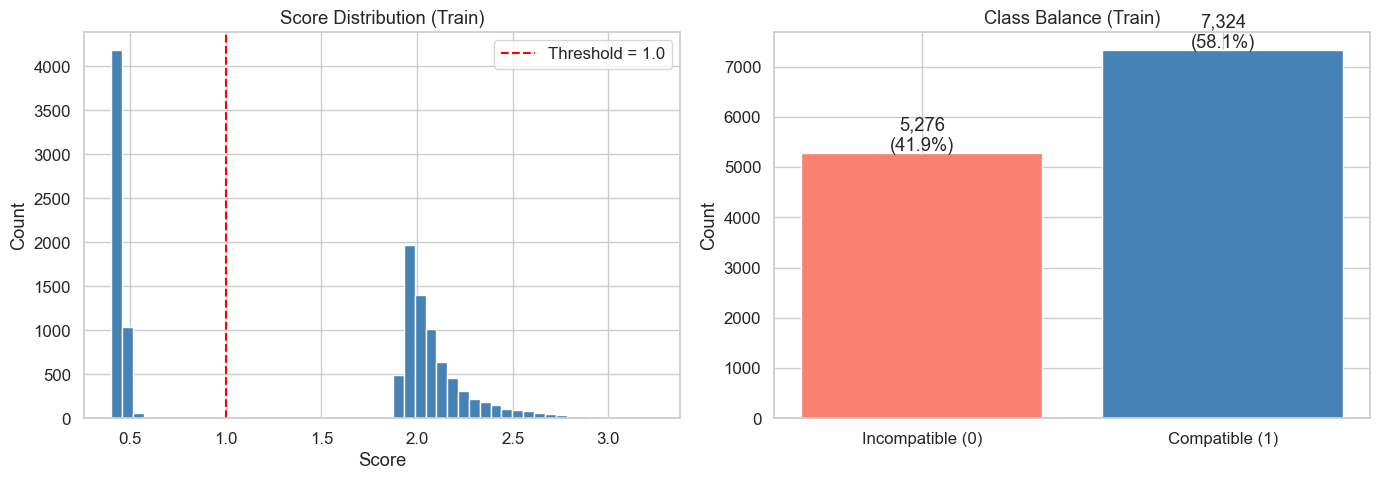

Positive rate: 58.1%


In [3]:
BINARY_THRESHOLD = 1.0
df_train['binary_label'] = (df_train['score'] >= BINARY_THRESHOLD).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score distribution
axes[0].hist(df_train['score'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(BINARY_THRESHOLD, color='red', linestyle='--', label=f'Threshold = {BINARY_THRESHOLD}')
axes[0].set_title('Score Distribution (Train)')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Count')
axes[0].legend()

# Class balance
counts = df_train['binary_label'].value_counts().sort_index()
axes[1].bar(['Incompatible (0)', 'Compatible (1)'], counts.values, color=['salmon', 'steelblue'])
axes[1].set_title('Class Balance (Train)')
axes[1].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 50, f'{v:,}\n({v/len(df_train)*100:.1f}%)', ha='center')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eda_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Positive rate: {df_train['binary_label'].mean()*100:.1f}%")

## Step 4: Physical Feature Sparsity

Physical attributes (`body_figure`, `skin_color`, `height`, etc.) are heavily missing.
This motivates the MICE imputation pipeline in NB03.

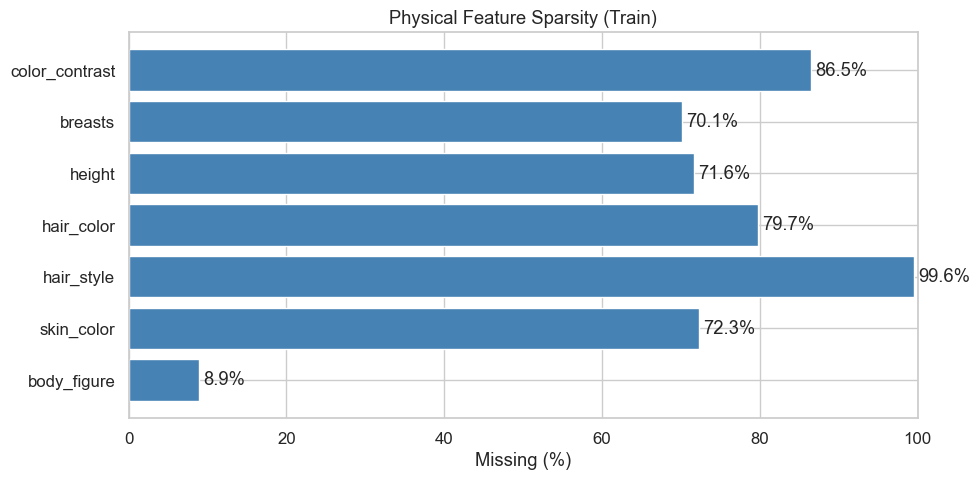

body_figure        8.944444
skin_color        72.349206
hair_style        99.595238
hair_color        79.730159
height            71.634921
breasts           70.095238
color_contrast    86.460317


In [4]:
PHYSICAL_COLS = ['body_figure', 'skin_color', 'hair_style', 'hair_color', 'height', 'breasts', 'color_contrast']

# Treat empty strings and None as missing
df_phys = df_train[PHYSICAL_COLS].replace({'': None, 'null': None, None: None})
missing_pct = df_phys.isnull().mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(missing_pct.index, missing_pct.values, color='steelblue')
ax.set_xlabel('Missing (%)')
ax.set_title('Physical Feature Sparsity (Train)')
ax.set_xlim(0, 100)
for bar, val in zip(bars, missing_pct.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eda_feature_sparsity.png', dpi=150, bbox_inches='tight')
plt.show()
print(missing_pct.to_string())

## Step 5: Body Figure Distribution

`body_figure` is a multi-label field (comma-separated). We inspect the most common values.

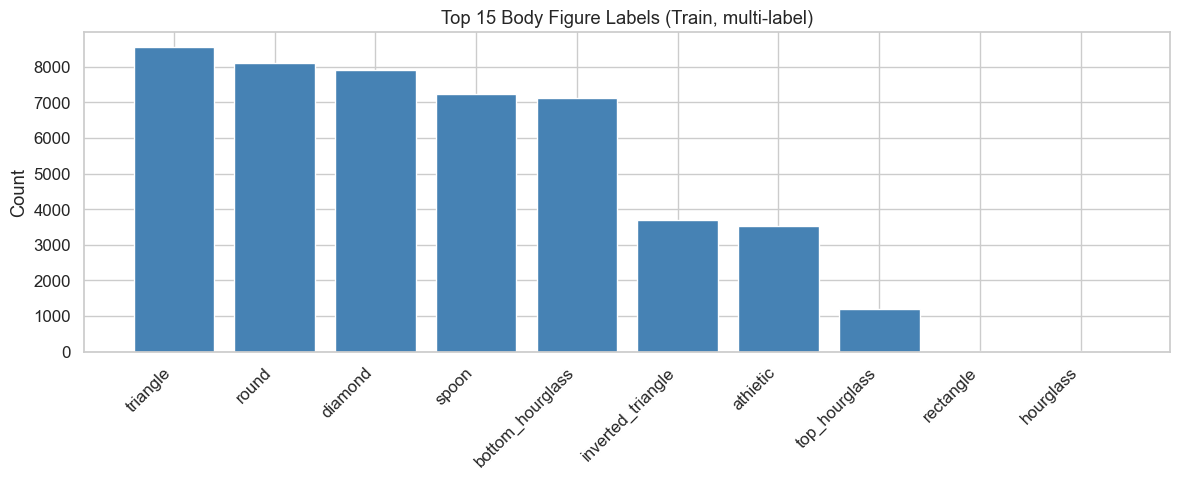

In [5]:
from collections import Counter

bf_series = df_train['body_figure'].dropna().replace('', None).dropna()
all_labels = []
for val in bf_series:
    all_labels.extend([v.strip().lower() for v in str(val).split(',') if v.strip()])

label_counts = Counter(all_labels)
top_labels = dict(sorted(label_counts.items(), key=lambda x: x[1], reverse=True)[:15])

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(top_labels.keys(), top_labels.values(), color='steelblue')
ax.set_title('Top 15 Body Figure Labels (Train, multi-label)')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Step 6: Items per Outfit

Each outfit contains 1–9 clothing items. The variable sequence length motivates the Transformer + attention pooling architecture.

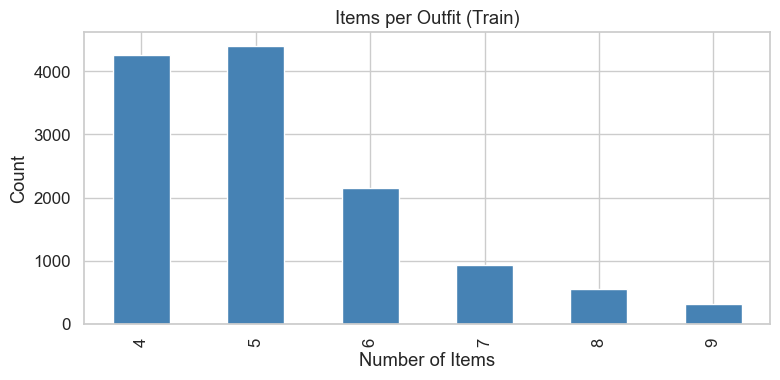

count    12600.000000
mean         5.209524
std          1.243855
min          4.000000
25%          4.000000
50%          5.000000
75%          6.000000
max          9.000000
dtype: float64


In [6]:
item_cols = [f'item_{i}' for i in range(1, 10)]
item_counts = df_train[item_cols].apply(
    lambda row: sum(1 for v in row if v and str(v).strip() not in ('', 'None', 'null')), axis=1
)

fig, ax = plt.subplots(figsize=(8, 4))
item_counts.value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Items per Outfit (Train)')
ax.set_xlabel('Number of Items')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()
print(item_counts.describe())

## Summary

| Finding | Implication |
|---|---|
| Score range 0.4 – 3.2, threshold at 1.0 | ~58% positive class — reasonably balanced |
| `height` and `breasts` are 40–60% missing | MICE imputation with RandomForestClassifier |
| `skin_color`, `hair_*`, `color_contrast` are 30–50% missing | Group-mode imputation |
| `body_figure` is multi-label, 20% missing | MultiLabelBinarizer + unknown fallback |
| 1–9 items per outfit (variable length) | Transformer + attention pooling in VisualBranch |

**Next step:** Run NB03 to execute the imputation pipeline and train the model.